In [11]:
try:
    import pandas as pd
    import missingno as msno 
    import matplotlib.pyplot as plt

    
except ImportError:
    !pip install --upgrade missingno, matplotlib, pandas
    import pandas as pd
    import matplotlib.pyplot as plt
    import missingno as msno
    

In [12]:
try:
    data_mkrf_movies=pd.read_csv("Наборы данных/mkrf_movies.csv",parse_dates=["show_start_date"])
    data_mkrf_shows=pd.read_csv("Наборы данных/mkrf_shows.csv")
except:
    data_mkrf_movies=pd.read_csv("/datasets/mkrf_movies.csv",parse_dates=["show_start_date"])
    data_mkrf_shows=pd.read_csv("/datasets/mkrf_shows.csv")
    

Описание проекта
--------------------------
Заказчик этого исследования — Министерство культуры Российской Федерации. 
Вам нужно изучить рынок российского кинопроката и выявить текущие тренды. Уделите внимание фильмам, которые получили государственную поддержку. Попробуйте ответить на вопрос, насколько такие фильмы интересны зрителю. 
Вы будете работать с данными, опубликованными на портале открытых данных Министерства культуры. Набор данных содержит информацию о прокатных удостоверениях, сборах и государственной поддержке фильмов, а также информацию с сайта КиноПоиск. 

Описание данных

Таблица mkrf_movies содержит информацию из реестра прокатных удостоверений. У одного фильма может быть несколько прокатных удостоверений. 

* title — название фильма;

* puNumber — номер прокатного удостоверения;

* show_start_date — дата премьеры фильма;

* type — тип фильма;

* film_studio — студия-производитель;

* production_country — страна-производитель;

* director — режиссёр;

* producer — продюсер;

* age_restriction — возрастная категория;

* refundable_support — объём возвратных средств государственной поддержки;

* nonrefundable_support — объём невозвратных средств государственной поддержки;

* financing_source — источник государственного финансирования;

* budget — общий бюджет фильма;

* ratings — рейтинг фильма на КиноПоиске;

* genres — жанр фильма.

Таблица mkrf_shows содержит сведения о показах фильмов в российских кинотеатрах.

* puNumber — номер прокатного удостоверения;

* box_office — сборы в рублях.

In [13]:
data_mkrf_movies.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [14]:
data_mkrf_shows.head(5)

,puNumber,box_office
0,111000113,2.450000e+03
1,111000115,6.104000e+04
2,111000116,1.530300e+08
3,111000117,1.226096e+07
4,111000118,1.636841e+08


In [15]:
data_mkrf_shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


In [16]:
data_mkrf_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7486 non-null   object             
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7468 non-null   object             
 5   production_country     7484 non-null   object             
 6   director               7477 non-null   object             
 7   producer               6918 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

Чтобы соединить 2 таблицы нужно чтобы puNumber в главной таблице был в числовом типе, преобразуем этот столбец в вещественный тип

In [17]:
data_mkrf_movies["puNumber"] = pd.to_numeric(data_mkrf_movies["puNumber"],errors='coerce')

In [18]:
data=pd.merge(data_mkrf_movies,data_mkrf_shows,how="left",on="puNumber")

In [21]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   title                  7486 non-null   object             
 1   puNumber               7485 non-null   float64            
 2   show_start_date        7486 non-null   datetime64[ns, UTC]
 3   type                   7486 non-null   object             
 4   film_studio            7468 non-null   object             
 5   production_country     7484 non-null   object             
 6   director               7477 non-null   object             
 7   producer               6918 non-null   object             
 8   age_restriction        7486 non-null   object             
 9   refundable_support     332 non-null    float64            
 10  nonrefundable_support  332 non-null    float64            
 11  budget                 332 non-null    float64          

In [22]:
data.shape[0]

7486

Объединение таблиц прошло без потери данных

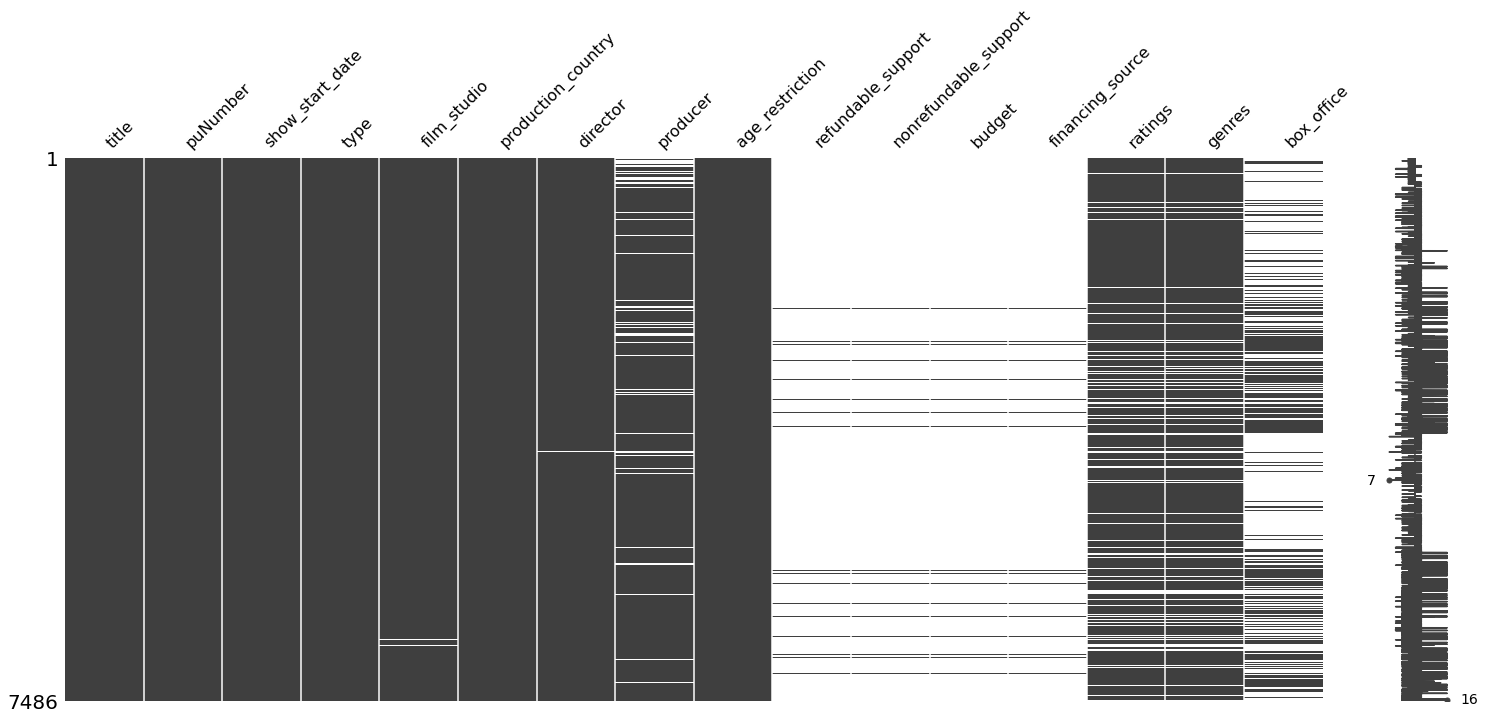

In [19]:
msno.matrix(data);

<AxesSubplot:>

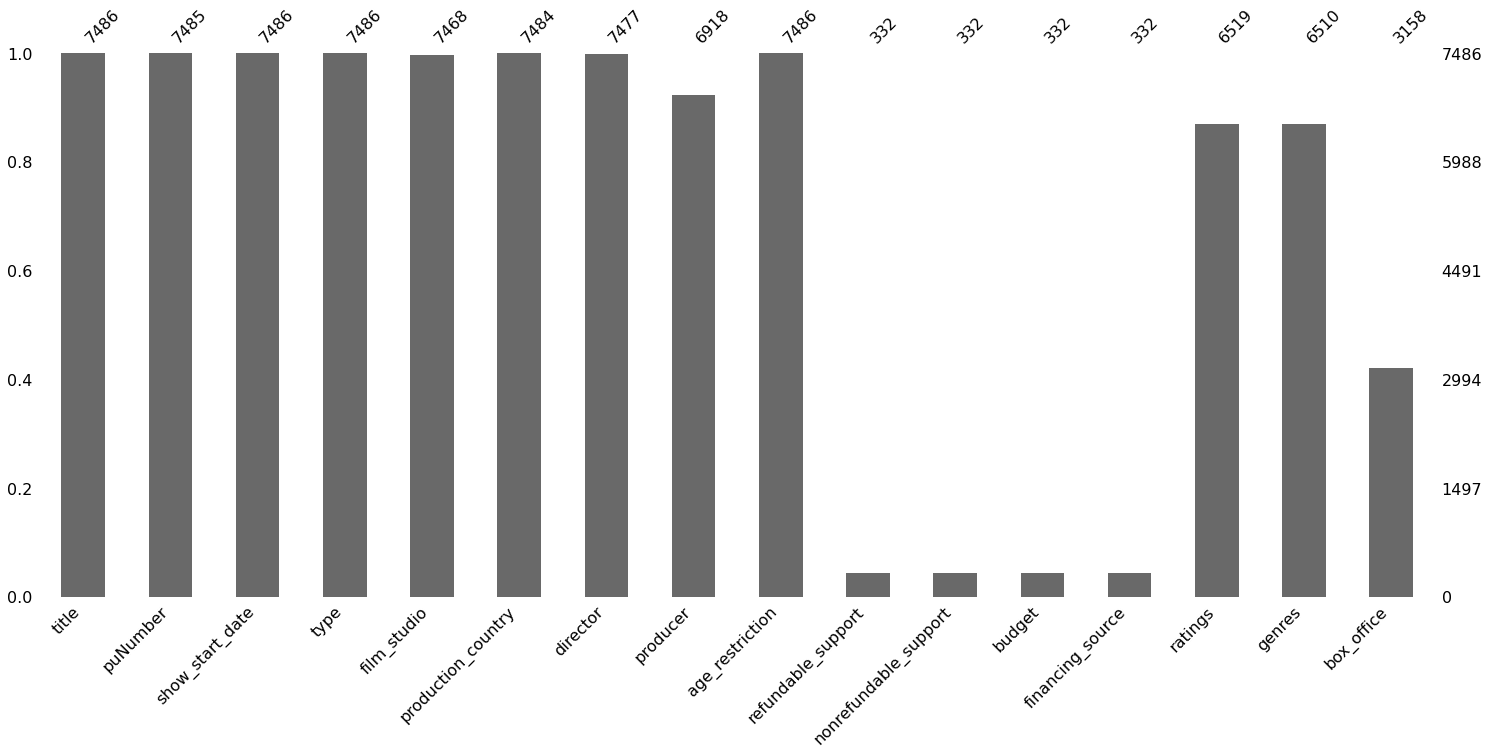

In [20]:
msno.bar(data)

Составим матрицу корреляции

In [1620]:
corr_data = data[["producer","ratings","genres","box_office"]].isna().corr()

In [1621]:
corr_data

,producer,ratings,genres,box_office
producer,1.000000,0.025012,0.023890,0.126270
ratings,0.025012,1.000000,0.994691,0.132209
genres,0.023890,0.994691,1.000000,0.130723
box_office,0.126270,0.132209,0.130723,1.000000


In [1622]:
data.isna().sum()

title                       0
puNumber                    1
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   967
genres                    976
box_office               4328
dtype: int64

Можно заметить, что присутствуют пропуски в столбцах puNumber, film_studio, production_country, roducer, refundable_support, nonrefundable_support, budget, financing_source, ratings, genres, box_office. Рассмотрим значения в столбцах в следующем шаге.

2 Предобработка данных
----------------------

Удалим одну строчку, в которой пропущено значение в столбце puNumber.

In [27]:
data = data[~data["puNumber"].isna()]

Изменим тип в столце puNumber на целочисленый

In [28]:
data["puNumber"] = data["puNumber"].astype("int32")

Также удалим строчки в которых пропущены значения в столбцах director,film_studio,production_country.

In [30]:
data = data[~data["film_studio"].isna()]
data = data[~data["director"].isna()]
data = data[~data["production_country"].isna()]

Мы удалили несколько строчек, потому что пропусков в столбцах мало относительно всего объема данных. Пропуски являются случаными, их нельзя никак объяснить, поэтому мы можем их удалить.

В столбцах producer, ratings, genres, удалять пропуски нельзя так как это сильно исказит результат анализа. Поэтому заполним пропущенные значения в столбце producer и genres значениями undef

In [31]:
data[["producer","genres"]] = data[["producer","genres"]].fillna("undef")

In [32]:
len(data[data["ratings"].isna()])/len(data)

0.1269777420219898

In [33]:
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,undef,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


Изменим тип в столбце ratings на вещественный

In [34]:
data["ratings"]=pd.to_numeric(data["ratings"],errors='coerce')

Так как в столбце ratings представлены рейтинги фильмов с портала КиноПоиск, то можно объяснить пропущенные значения в этом столбце тем, что некоторых фильмов нету в КиноПоиске. Поэтому заменим пропущенные значения на -1. (Заменяем на -1 так как рейтинг 0 может быть у других фильмов)

In [35]:
data["ratings"] = data["ratings"].fillna(-1)

В целом пропуски в столбцах refundable_support, nonrefundable_support, budget, financing_source можно не трогать, так как в этих столбцах хранится информация о фильмах с государственной поддержкой. По ходу анализа, можно будет по пропускам разбить данные на 2 таблицы. Первая таблица будет хранить информацию о фильмах без государственной поддержки, второя таблица будет хранить информацию о фильмах с государственной поддержкой.

In [36]:
#data[["refundable_support","nonrefundable_support","budget","financing_source"]] = data[["refundable_support","nonrefundable_support","budget","financing_source"]].fillna(-1)

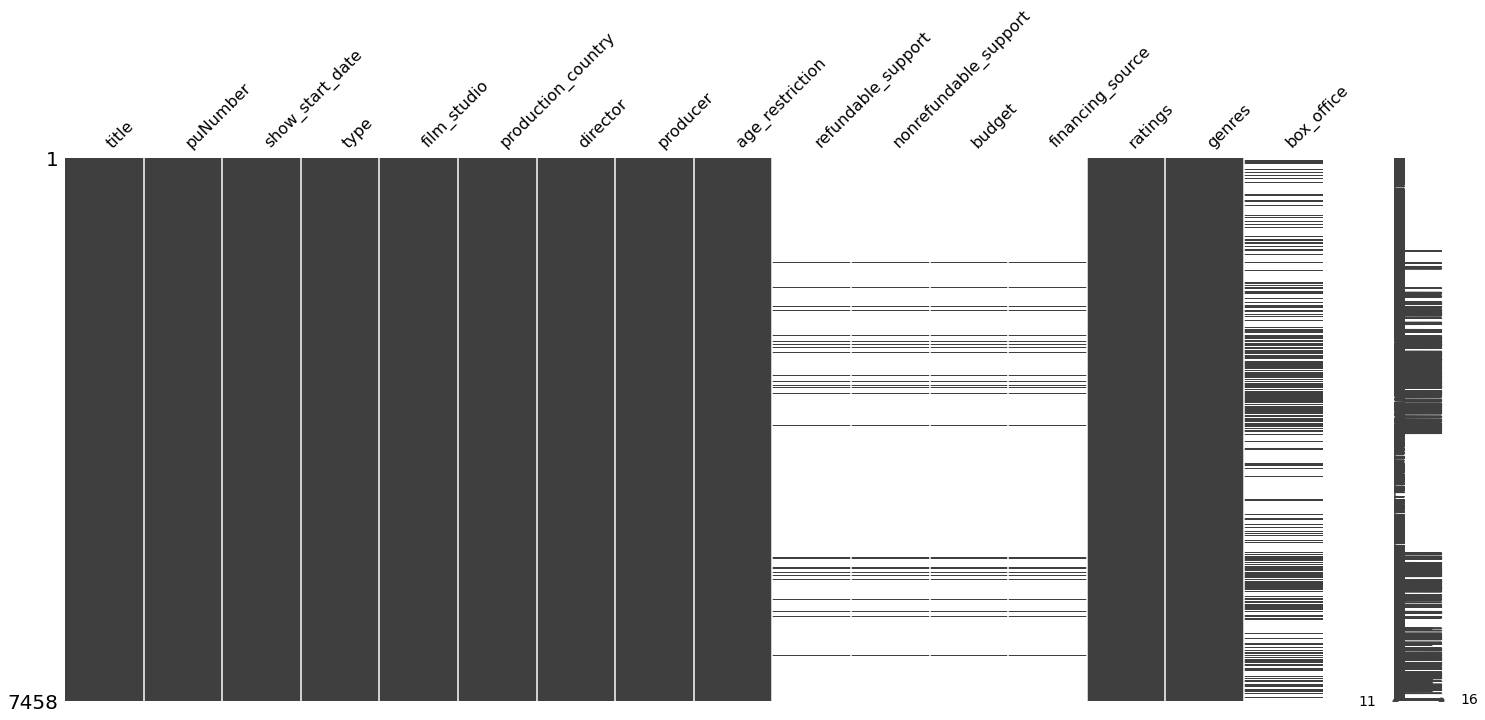

In [37]:
msno.matrix(data);

В столбце box_office так же оставим пропуски, т.к. на 0 мы не можем заменить, потому что у некоторых фильмов может быть реально кассовый сбор равный 0.

Выявление дубликатов
--------------

In [38]:
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,undef,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN


In [39]:
len(data[data.duplicated(subset=["title","director"])])

682

In [40]:
data = data.drop_duplicates(subset=["title","director"])

In [41]:
len(data)

6776

Изучение столбцов с категориальными переменными
------------------

In [42]:
data.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
0,Открытый простор,221048915,2015-11-27 12:00:00+00:00,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама",NaN
1,Особо важное задание,111013716,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,undef,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный",NaN
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер",NaN
5,Остановился поезд,111013816,2016-09-13 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Абдрашитов,undef,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,7.7,драма,NaN
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,undef,«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,8.3,"мелодрама,комедия",2700.0


In [43]:
data.type.unique()

array(['Художественный', 'Анимационный', 'Прочие', 'Документальный',
       'Научно-популярный', ' Художественный', ' Анимационный',
       'Музыкально-развлекательный'], dtype=object)

In [44]:
data.type = data.type.str.strip()

Мы убрали неявные дубликаты

Мы можем заметить, что в столбце production_country разделителями между странами являются либо запятая, либо тире. Приведем к единому виду, пусть разделителем будет запятая

In [45]:
data.production_country = data.production_country.str.replace(' ','').str.replace('-',',')

In [46]:
data = data.reset_index(drop=True)

Изменим вид столбца age_restriction, оставим только цифры, для удобства работы

In [47]:
data.age_restriction.unique()

array(['«18+» - запрещено для детей', '«6+» - для детей старше 6 лет',
       '«12+» - для детей старше 12 лет',
       '«16+» - для детей старше 16 лет',
       '«0+» - для любой зрительской аудитории'], dtype=object)

In [48]:
def change_view(data):
    if "18" in data:
        return "18"
    elif "16" in data:
        return "16"
    elif "12" in data:
        return "12"
    elif "6" in data:
        return "6"
    else:
        return "0"
    
data.age_restriction = data.age_restriction.apply(change_view)

Изменим тип в столбце age_restriction на целочисленный

In [49]:
data.age_restriction = data.age_restriction.astype("int")

Добавление новых столбцов
----------

In [50]:
data["year"] = data["show_start_date"].dt.year

In [51]:
def information_extraction(data):
    if ',' in data:
        return data.split(',')[0]
    else:
        return data


data["name_director"] = data['director'].apply(information_extraction)
data["main_genre"]=data["genres"].apply(information_extraction)

Изучение столбцов с количественными переменными
------------

Создадим 2 дадасета. В первом будут только фильмы, которые профинансировало государство. Второй будет копией основного датасета


In [52]:
data_sponsored_films = data[~data["financing_source"].isna()]

In [53]:
data_sponsored_films = data_sponsored_films.reset_index(drop=True)

Добавим новый столбец в data_sponsored_films, в котором будет информация о доле государственной поддержки от общего бюджета.

In [54]:
#def finding_share(data):
#    if data["budget"]==0:
#        return 1
#    else:
#        return (data["refundable_support"]+data["nonrefundable_support"])/data["budget"]


#data_sponsored_films["share_of_state_support"] = data_sponsored_films.apply(finding_share,axis=1)
pd.set_option('display.max_rows', None)
data_sponsored_films["share_of_state_support"]=(data_sponsored_films["refundable_support"]+data_sponsored_films["nonrefundable_support"])/data_sponsored_films["budget"]

In [55]:
len(data_sponsored_films.query('budget == 0'))

17

Удалим строки, в которых budget равен 0, так как они являются аномальными. 

In [56]:
data_sponsored_films = data_sponsored_films.query('budget != 0')

In [57]:
data_sponsored_films

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,name_director,main_genre,share_of_state_support
0,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",16,0.0,26500000.0,7.941190e+07,Министерство культуры,8.1,"драма,мелодрама",3.653536e+05,2013,А.Атанесян,драма,0.333703
1,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,12,0.0,26000000.0,3.714286e+07,Министерство культуры,-1.0,undef,2.814000e+04,2014,А.Якимчук,undef,0.700000
2,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",12,0.0,107847945.0,1.760235e+08,Фонд кино,5.3,"комедия,фантастика",1.995703e+07,2013,Р.Давлетьяров,комедия,0.612691
3,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,16,0.0,28000000.0,4.057414e+07,Министерство культуры,4.2,драма,5.591750e+04,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,0.690095
4,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",16,0.0,25000000.0,4.001512e+07,Министерство культуры,6.4,драма,2.321000e+05,2014,М.Угаров,драма,0.624764
5,Тайна Сухаревой башни. Чародей равновесия,114000115,2015-02-18 12:00:00+00:00,Анимационный,"ООО ""Студия ""Мастер-Фильм""",Россия,С.Серегин,А.Герасимов,6,0.0,25000000.0,5.185000e+07,Министерство культуры,6.1,"мультфильм,фэнтези,история",1.507886e+07,2015,С.Серегин,мультфильм,0.482160
6,А зори здесь тихие..._,111002915,2015-03-16 12:00:00+00:00,Художественный,"ООО ""Компания ""Реал-Дакота""",Россия,Р.Давлетьяров,undef,12,50000000.0,100000000.0,2.205884e+08,Фонд кино,8.5,"драма,военный,история",2.491668e+08,2015,Р.Давлетьяров,драма,0.680000
7,Две женщины,111013714,2014-10-02 12:00:00+00:00,Художественный,"ООО ""Продюсерский Центр ""Хорошо Продакшн"", Rez...","Россия,Франция,Латвия",В.Глаголева,Н.Иванова,12,0.0,46502299.0,8.621007e+07,"Министерство культуры, Фонд кино",6.7,драма,4.731240e+06,2014,В.Глаголева,драма,0.539407
8,Призрак_.,111001815,2015-03-02 12:00:00+00:00,Художественный,"ООО ""Водород 2011""",Россия,А.Войтинский,С.Сельянов,6,0.0,75000000.0,1.395515e+08,Фонд кино,7.0,"триллер,боевик,приключения",3.528043e+08,2015,А.Войтинский,триллер,0.537436
9,Ведьма .,111002215,2015-03-05 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""Ракурс""",Россия,Д.Федоров,В.Сидоренко,16,0.0,34000000.0,4.857143e+07,Министерство культуры,7.4,"фэнтези,приключения,драма",5.190750e+04,2015,Д.Федоров,фэнтези,0.700000


Во втором датасете не будет столбцов  refundable_support, nonrefundable_support, budget потому что в них хранится информация о фильмах, которых поддержало государство. Оставим только столбец financing_source для того чтобы в будующем разграничить фильмы на две группы.

In [58]:
data_main = data[["title","show_start_date","type","production_country","director","producer","age_restriction","financing_source","ratings","genres","box_office","year","name_director","main_genre"]]

Рассмотрим столбец box_office в таблице data_main
----------------------

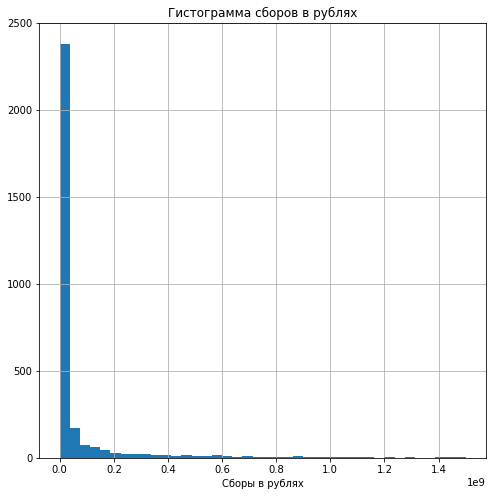

In [64]:
data_main["box_office"].hist(figsize=(8,8),bins=40,range=(0,15_000_000_00));
plt.title("Гистограмма сборов в рублях");
plt.xlabel("Сборы в рублях");

In [65]:
len(data_main.query('box_office >= 0'))

3024

In [66]:
len(data_main.query('box_office> 0.6*10**9'))

108

Можно заметить, что основная масса значений сосредоточена в начале, а после 0.6 наблюдается резкий спад.

Обрезка выборки – разумно исключить значения > 0.6, так как они встречаются редко и могут считаться редкими значениями.


In [67]:
data_main = data_main.query('box_office not in (box_office > 0.6*10**9)')

Рассмотрим переменные из столбца ratings в таблице data_main
---------------

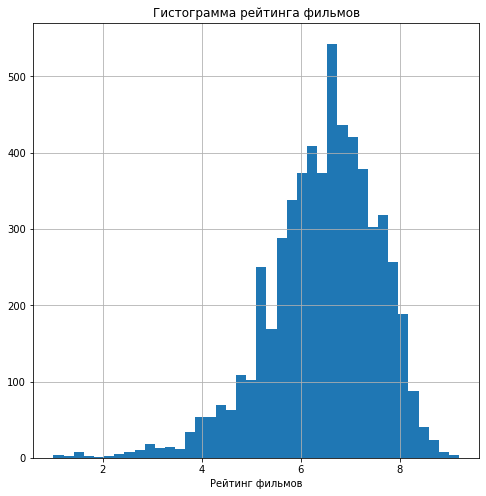

In [69]:
data_main.query('ratings>0')["ratings"].hist(figsize=(8,8),bins=40);
plt.xlabel('Рейтинг фильмов');
plt.title('Гистограмма рейтинга фильмов');

In [1659]:
len(data_main.query('0<ratings<3')["ratings"])

53

1) Распределение значений демонстрирует сходство с нормальным распределением:
   * Основная масса значений сосредоточена вокруг центра
   * Наблюдается симметричное убывание частоты значений по мере удаления от центра

     
2) Однако обнаружено существенное отклонение от нормального распределения:
   * Левый хвост распределения аномально длинный
   * Наблюдается избыток экстремально низких значений
     
Предложение:

Убрать из выборки значения от 0 до 3, это позволит избавиться от экстремально низких значений 



In [1660]:
data_main=data_main.query('ratings not in (0<ratings<3)')

In [1661]:
len(data_main)

6751

Рассмотрим таблицу data_sponsored_films
----------

Таблица data_sponsored_films содержит малое количество наблюдений, поэтому агрессивная обрезка может привести к критической потере данных.

Решение:

Удалим только экстремальные выбросы, сохранив основную массу значений.

In [1662]:
len(data_sponsored_films)

314

Рассмотрим переменные из столбца refundable_support
-

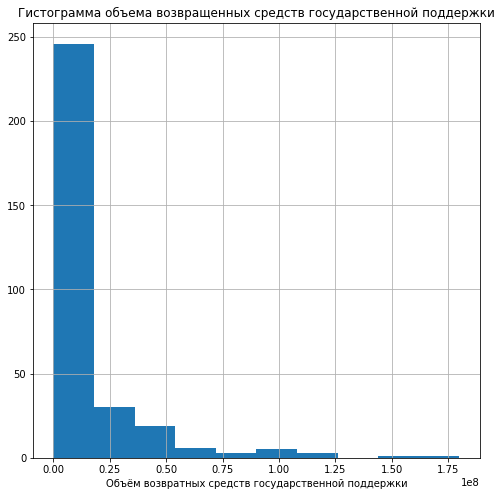

In [73]:
data_sponsored_films.refundable_support.hist(figsize=(8,8),bins=10);
plt.xlabel("Объём возвратных средств государственной поддержки");
plt.title("Гистограмма объема возвращенных средств государственной поддержки");

In [74]:
len(data_sponsored_films)

314

Анализ распределения данных:

1) Гистограмма показывает наличие редких значений - всего 2 фильма попадают в эту категорию.
   
Решение:
Поскольку эти 5 значений являются выбросами и искажают общую картину данных, их следует исключить из выборки для дальнейшего анализа.
ализа."

In [75]:
len(data_sponsored_films.query("refundable_support > 130_000_000"))

2

In [76]:
data_sponsored_films = data_sponsored_films.query("refundable_support < 130_000_000")

Рассмотрим переменные из столбца nonrefundable_support
---------

Text(0.5, 1.0, 'Гистограмма объёма невозвратных средств государственной поддержки')

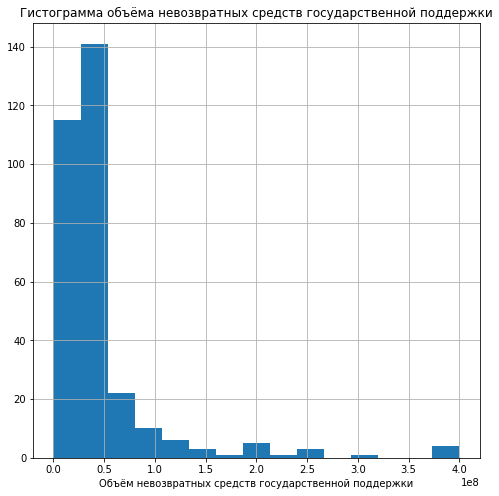

In [77]:
data_sponsored_films.nonrefundable_support.hist( figsize=(8,8),bins=15);
plt.xlabel('Объём невозвратных средств государственной поддержки');
plt.title("Гистограмма объёма невозвратных средств государственной поддержки")

In [78]:
len(data_sponsored_films)

312

In [79]:
len(data_sponsored_films.query('nonrefundable_support>2.9*10**8'))

5

Анализ распределения данных:

1) Гистограмма показывает наличие редких значений - примерно начиная с 290_000_000_

Решение:
Поскольку эти аномальные значений являются выбросами и искажают общую картину данных, их следует исключить из выборки для дальнейшего анализа.

In [80]:
data_sponsored_films = data_sponsored_films.query('nonrefundable_support < 2.9*10**8')

Рассмотрим переменные из столбца budget
--------------

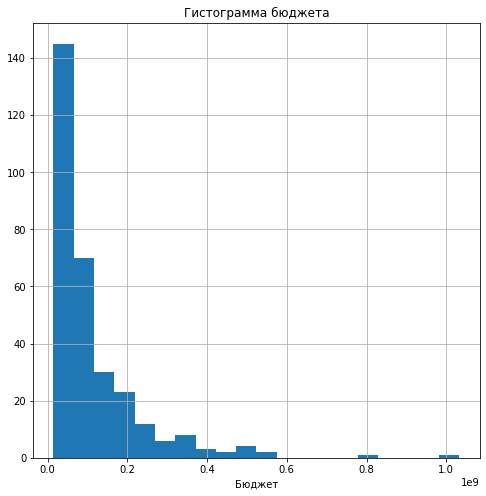

In [82]:
data_sponsored_films.budget.hist( figsize=(8,8),bins=20);
plt.xlabel('Бюджет');
plt.title('Гистограмма бюджета');

In [83]:
data_sponsored_films.query('budget > 0.7*10**9')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,name_director,main_genre,share_of_state_support
186,Матильда,111005717,2017-08-17 12:00:00+00:00,Художественный,"ООО ""ТПО ""РОК"", ООО ""Матильда""",Россия,А.Учитель,"А.Учитель, А.Достман, В.Винокур",16,110000000.0,190000000.0,1.032906e+09,Фонд кино,7.7,"фэнтези,комедия,семейный",5.117755e+08,2017,А.Учитель,фэнтези,0.290443
311,Грех,111014419,2019-08-31 12:00:00+00:00,Художественный,НО Фонд Андрея Кончаловского по поддержке кино...,"Россия,Италия",А.Михалков (псевдоним А.Кончаловский),НО Фонд Андрея Кончаловского по поддержке кино...,16,0.0,60000000.0,7.799420e+08,Министерство культуры,6.9,"драма,биография,история",5.424320e+07,2019,А.Михалков (псевдоним А.Кончаловский),драма,0.076929


Удалим аномальные значения из выборки

In [84]:
data_sponsored_films = data_sponsored_films.query('budget<0.7*10**9')

Рассмотрим переменные из столбца ratings
---------

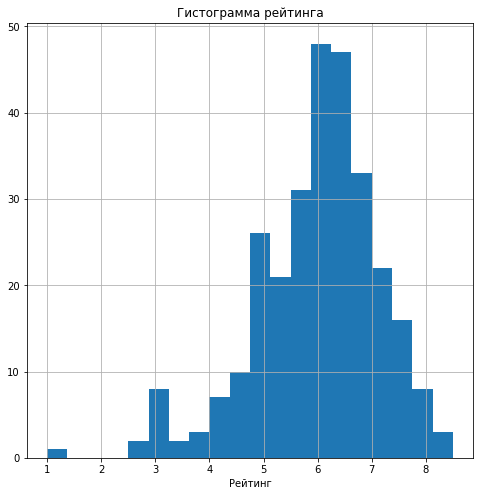

In [86]:
data_sponsored_films.query('ratings>0').ratings.hist(figsize=(8,8),bins=20);
plt.title('Гистограмма рейтинга');
plt.xlabel('Рейтинг');

In [87]:
data_sponsored_films.query('1<=ratings<=3')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,name_director,main_genre,share_of_state_support
105,Богатырша,114003715,2015-12-23 12:00:00+00:00,Анимационный,"ООО ""Продюсерский центр ""Парадиз""",Россия,О.Лопато,"Г.Нерсисян, А.Манасарян, А.Гюлумян, В.Саргсян",6,15000000.0,15000000.0,62044646.0,Фонд кино,2.8,мультфильм,3.833450e+07,2015,О.Лопато,мультфильм,0.483523
136,Крым (2017),111002017,2017-04-12 12:00:00+00:00,Художественный,"ООО ""Пиманов и партнеры""",Россия,А.Пиманов,А.Пиманов,16,20000000.0,30123915.0,222513841.0,Фонд кино,2.9,"драма,боевик",3.428987e+08,2017,А.Пиманов,драма,0.225262
151,Защитники,111000717,2017-01-24 12:00:00+00:00,Художественный,"ООО ""Энджой мувиз"", ООО ""РЕНОВАЦИО интертейнмент""",Россия,С.Андреасян,"С.Андреасян, Г.Андреасян, В.Поляков, А.Рязанцев",12,50000000.0,150000000.0,323232109.0,Фонд кино,3.0,"фантастика,фэнтези,боевик",2.620403e+08,2017,С.Андреасян,фантастика,0.618750
157,Взломать блогеров,111016616,2016-10-28 12:00:00+00:00,Художественный,"ООО ""ТаББаК""",Россия,М.Свешников,Т.Бекмамбетов,6,0.0,25000000.0,36016269.0,Фонд кино,1.0,"комедия,мультфильм,фантастика",7.323648e+06,2016,М.Свешников,комедия,0.694131
176,Спасти Пушкина,111002517,2017-04-13 12:00:00+00:00,Художественный,"ООО ""Каро Продакшн""",Россия,Ф.Коршунов при участии П.Мирзоева,"Ю.Обухов, А.Рязанцев",6,0.0,40000000.0,65000000.0,Министерство культуры,2.9,"комедия,фантастика",5.729521e+06,2017,Ф.Коршунов при участии П.Мирзоева,комедия,0.615385
255,Крымский мост. Сделано с любовью,111020018,2018-10-29 12:00:00+00:00,Художественный,"ООО ""Студия ""8 рядов""",Россия,Т.Кеосаян,Д.Кеосаян,12,0.0,100000000.0,154245687.0,Фонд кино,2.5,"комедия,мелодрама",7.079867e+07,2018,Т.Кеосаян,комедия,0.648316


Удалим эти строки из data_sponsored_films, чтобы привести распределение переменных к нормальному распределению

In [88]:
data_sponsored_films=data_sponsored_films.drop(data_sponsored_films.query('1<=ratings<=3.5').index)
data_sponsored_films=data_sponsored_films.reset_index(drop=True)

In [89]:
#data_sponsored_films = data_sponsored_films.query('ratings not in (1<= ratings <=3.5)') почему-то у меня не получилось через этот запрос удалить строчки

Рассмотрим переменные из столбца box_office
--------------

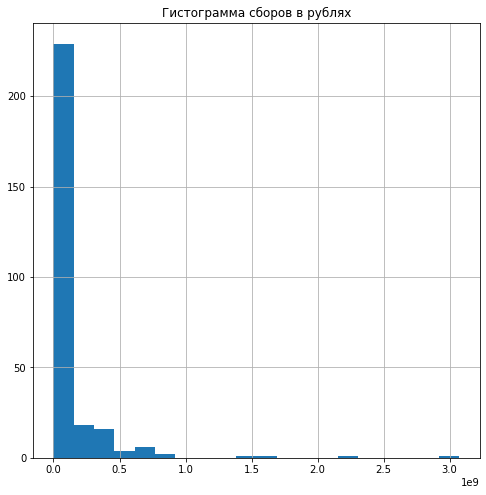

In [92]:
data_sponsored_films.query('box_office>0').box_office.hist(figsize=(8,8),bins=20)
plt.title("Гистограмма сборов в рублях");

In [93]:
len(data_sponsored_films)

292

In [94]:
data_sponsored_films.query('box_office>1*10**9')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,name_director,main_genre,share_of_state_support
167,Последний богатырь,111007017,2017-10-19 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"" по заказу ООО ""Уолт Ди...",Россия,Д.Дьяченко,"Э.Илоян, Д.Жалинский, М.Озкан, А.Троцюк, В.Шляппо",12,50000000.0,50000000.0,352477575.0,Фонд кино,6.8,"комедия,фэнтези,приключения",1.655038e+09,2017,Д.Дьяченко,комедия,0.283706
186,Лёд,111000518,2018-02-01 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия"", ...",Россия,О.Трофим,"М.Врубель, А.Андрющенко, Ф.Бондарчук, Д.Рудовс...",12,25000000.0,60000000.0,148585222.0,Фонд кино,-1.0,undef,1.445732e+09,2018,О.Трофим,undef,0.572062
229,Т-34,111024918,2018-12-21 12:00:00+00:00,Художественный,"ООО ""Кинокомпания МАРС-фильм"" по заказу ООО ""М...",Россия,А.Сидоров,"А.Златопольский, Р.Дишдишян, Л.Блаватник, Н.Яр...",12,60000000.0,120000000.0,563784717.0,Фонд кино,6.5,"драма,военный,боевик",2.271754e+09,2018,А.Сидоров,драма,0.319271
288,Холоп,111021719,2019-12-19 12:00:00+00:00,Художественный,"ООО ""МЕМ-МЕДИА"" по заказу АО ""ВБД Груп""",Россия,К.Шипенко,"Э.Илоян, Д.Жалинский, В.Дусмухаметов, Т.Бадзие...",12,25000000.0,35000000.0,160000000.0,Фонд кино,6.8,комедия,3.073569e+09,2019,К.Шипенко,комедия,0.375000


Удалим редкие значения из выборки

In [95]:
data_sponsored_films=data_sponsored_films.drop(data_sponsored_films.query('box_office>1*10**9').index)
data_sponsored_films=data_sponsored_films.reset_index(drop=True)

In [96]:
len(data_sponsored_films)

288

------------------------

In [97]:
data_sponsored_films.shape[0]/314

0.9171974522292994

Мы убрали 8 процентов данных

Вывод: в ходе предварительного анализа были исключены редкие и аномальные значения в количественных переменных, что позволит минимизировать их искажающее влияяние на последущие этапы обработки данных.

Исследовательский анализ данных
-----------

In [99]:
data_main.query('year == 2010')["box_office"].isna().sum()

669

In [100]:
len(data_main.query('year == 2010'))

753

In [101]:
data_rental = data_main.pivot_table(index="year",values=["title","box_office"],aggfunc="count")

In [102]:
data_rental['sahre'] = data_rental['box_office']/data_rental['title']*100

In [103]:
data_rental.columns = ['amount_incomplete_data','total_quantity','share']

In [104]:
data_rental

,amount_incomplete_data,total_quantity,share
year,,,
2010,84,753,11.155378
2011,98,475,20.631579
2012,110,511,21.526419
2013,171,584,29.280822
2014,251,722,34.764543
2015,428,658,65.045593
2016,499,769,64.889467
2017,357,500,71.400000
2018,473,871,54.305396


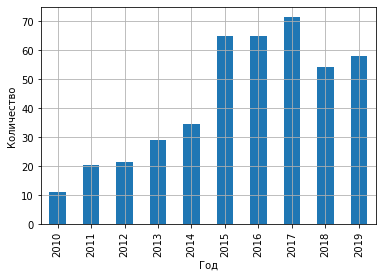

In [105]:
data_rental["share"].plot(kind="bar",grid=True,legend=False);
plt.xlabel("Год");
plt.ylabel("Количество");

Полнее всего представлен 2017 год, менее всего представлен 2010 год

Изменение динамики по годам
----------

In [106]:
data_sum = data_main.pivot_table(index="year",values="box_office",aggfunc="sum")

In [107]:
data_sum

,box_office
year,
2010,2.374340e+06
2011,1.394439e+07
2012,6.420761e+06
2013,2.976853e+07
2014,7.372599e+09
2015,3.208465e+10
2016,4.373125e+10
2017,4.856371e+10
2018,4.798568e+10


In [108]:
data_sum = data_sum["box_office"]/10**6

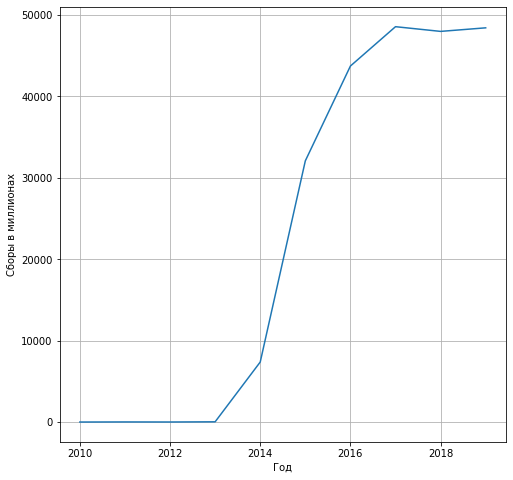

In [109]:
data_sum.reset_index().plot(x="year",y="box_office",grid=True,legend=False,figsize=(8,8));
plt.xlabel('Год');
plt.ylabel('Сборы в миллионах');

в 2017 году сумма сборов достигла максимального значения за весь период, тогда как в 2010 году была зафиксирована минимальная сумма за тот же период(это видно в сводной таблице)

<div class="alert alert-block alert-success">
 
### Комментарий ревьюера
    
#### Успех

С выводами согласен 

Сравнеие средней и медианной суммы сборов по каждому году
------------

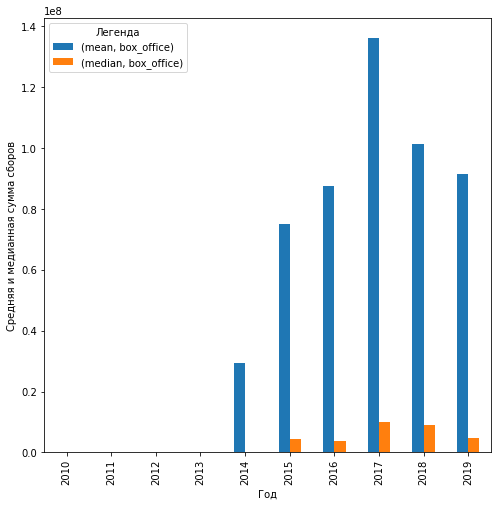

In [114]:
(data_main
    .pivot_table(index="year",values="box_office",aggfunc=["mean","median"])
    .plot(kind="bar",figsize=(8,8),legend=False,xlabel="Год",ylabel="Средняя и медианная сумма сборов")
    .legend(title="Легенда")
);

<div class="alert alert-block alert-danger">
 
### Комментарий ревьюера
    
#### Ошибка

Без легенды не графике сложно понять где медианные значения, а где средние. Давай добавим.

<div class="alert-info">
<br>А как исправить через точку названия столбцов?
<br>.rename(columns={('mean','box_office'):'mean',('median','box_office'):'median'})

<div class="alert alert-block alert-warning">
 
# Комментарий ревьюера ver.2 
    
#### Совет

К сожалению не совсем понял твой вопрос тут? что значит через точку названия? 

Можно заметить, что средняя сумма сильно отличается от медианной, это можно объяснить тем что в данных есть аномально высокие значения, которые влияют на сумму сборов. Поэтому для анализа лучше использовать медианные значения.

Влияние возрастного ограничения на сборы фильмов в прокате с 2015 по 2019 года
-------

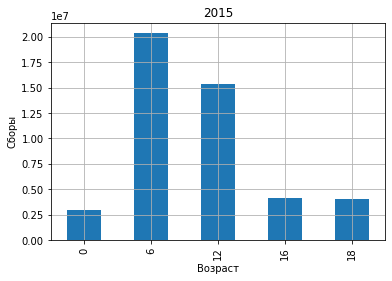

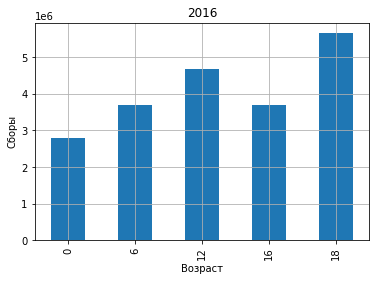

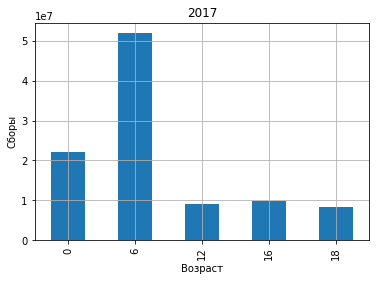

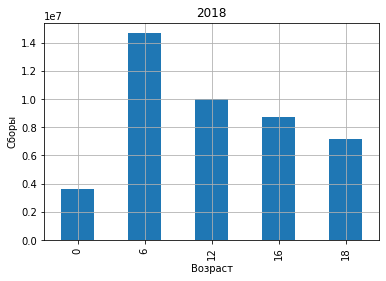

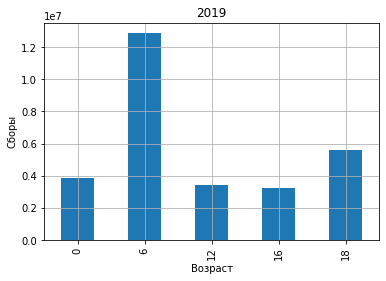

In [146]:
(data_main
     .query('2015==year')
     .pivot_table(index=["age_restriction"],values="box_office",aggfunc="median")
     .plot(kind="bar",grid=True,legend=False,xlabel="Возраст",ylabel="Сборы",title="2015")
);


(data_main
     .query('2016==year')
     .pivot_table(index=["age_restriction"],values="box_office",aggfunc="median")
     .plot(kind="bar",grid=True,legend=False,xlabel="Возраст",ylabel="Сборы",title="2016")
);

(data_main
     .query('2017==year')
     .pivot_table(index=["age_restriction"],values="box_office",aggfunc="median")
     .plot(kind="bar",grid=True,legend=False,xlabel="Возраст",ylabel="Сборы",title="2017")
);

(data_main
     .query('2018==year')
     .pivot_table(index=["age_restriction"],values="box_office",aggfunc="median")
     .plot(kind="bar",grid=True,legend=False,xlabel="Возраст",ylabel="Сборы",title="2018")
);

(data_main
     .query('2019==year')
     .pivot_table(index=["age_restriction"],values="box_office",aggfunc="median")
     .plot(kind="bar",grid=True,legend=False,xlabel="Возраст",ylabel="Сборы",title="2019")
);




<div class="alert alert-block alert-danger">
 
### Комментарий ревьюера
    
#### Ошибка

Тут давай график чуть подправим. Не должен год выглядеть так на оси X. Лучше год выпуска привести к целочисленному формату

<div class="alert-info">
<br>Исправил


<div class="alert alert-block alert-success">
 
# Комментарий ревьюера ver.2 
    
#### Успех

Теперь здророво и тут 

В 2015, 2017, 2018 и 2019 годах фильмы с рейтингом 6+ собрали наибольшие кассовые сборы. Однако в 2016 году лидером стали фильмы с ограничением 18+, что выделяет этот год на фоне остальных.

Исследование фильмов, которые получили государственную поддержку
-----------------

In [129]:
data_sponsored_films.head(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,year,name_director,main_genre,share_of_state_support
0,Пока еще жива,111005313,2013-10-11 12:00:00+00:00,Художественный,"АНО содействия развитию кинематографии ""Ангел-...",Россия,А.Атанесян,"А.Атанесян, М.Бабаханов, Р.Бутко",16,0.0,26500000.0,79411900.0,Министерство культуры,8.1,"драма,мелодрама",365353.6,2013,А.Атанесян,драма,0.333703
1,Бесславные придурки,111003314,2014-03-28 12:00:00+00:00,Художественный,"ООО ""Компания ""АТК-Студио""",Россия,А.Якимчук,А.Тютрюмов,12,0.0,26000000.0,37142857.0,Министерство культуры,-1.0,undef,28140.0,2014,А.Якимчук,undef,0.700000
2,Невидимки,111004213,2013-09-10 12:00:00+00:00,Художественный,"ООО ""Компания ""РЕАЛ-ДАКОТА""",Россия,"Р.Давлетьяров, С.Комаров","Р.Давлетьяров, А.Котелевский, А.Олейников",12,0.0,107847945.0,176023490.0,Фонд кино,5.3,"комедия,фантастика",19957031.5,2013,Р.Давлетьяров,комедия,0.612691
3,БЕРЦЫ,111004314,2014-05-05 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,Е.Миндадзе (псевдоним Катя Шагалова),Л.Антонова,16,0.0,28000000.0,40574140.0,Министерство культуры,4.2,драма,55917.5,2014,Е.Миндадзе (псевдоним Катя Шагалова),драма,0.690095
4,Братья Ч,111004414,2014-04-23 12:00:00+00:00,Художественный,"ООО ""Студия ""Пассажир""",Россия,М.Угаров,"А.Миндадзе, Л.Антонова",16,0.0,25000000.0,40015122.0,Министерство культуры,6.4,драма,232100.0,2014,М.Угаров,драма,0.624764


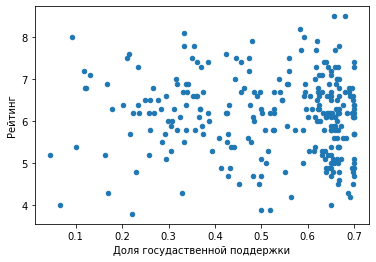

In [130]:
(data_sponsored_films
     .query('ratings != -1')
     .plot(x="share_of_state_support",y="ratings",kind="scatter",ylabel="Рейтинг",xlabel="Доля госудаственной поддержки")
     
);

Между рейтингом и долей государственной поддержки связь не наблюдается. 

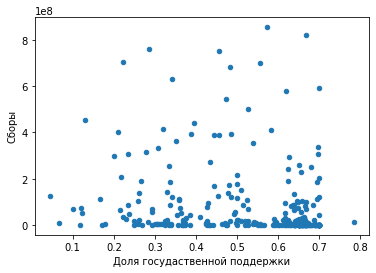

In [131]:
(data_sponsored_films
     .plot(x="share_of_state_support",y="box_office",kind="scatter",ylabel="Сборы",xlabel="Доля госудаственной поддержки")
     
);

In [132]:
data_sponsored_films.share_of_state_support.corr(data_sponsored_films.box_office)

-0.18644317364469934

Связь между долей государственной поддержки и сборами не обнаружена.

<div class="alert alert-block alert-success">
 
### Комментарий ревьюера
    
#### Успех

Использован удобный метод для показа зависимости на графике. Связи реально нет 

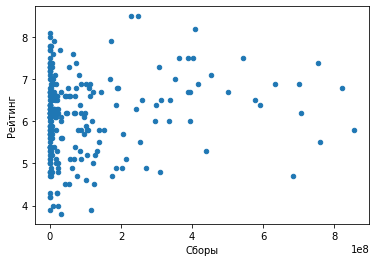

In [133]:
(data_sponsored_films
     .query('ratings>-1')
     .plot(x="box_office",y="ratings",kind="scatter",ylabel="Рейтинг",xlabel="Сборы")
     
);

In [134]:
data_sponsored_films.box_office.corr(data_sponsored_films.ratings)

0.16802412485858303

Связь между рейтингом и сборами не обнаружена.

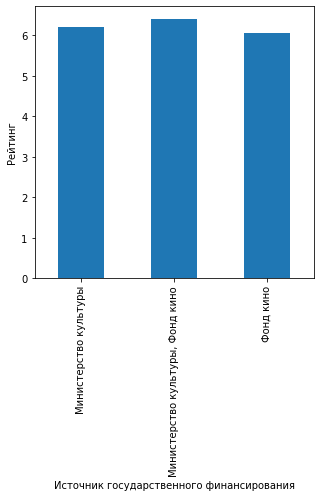

In [135]:
(data_sponsored_films
     .pivot_table(index="financing_source",values="ratings",aggfunc="median")
     .plot(kind="bar",figsize=(5,5),legend=False,xlabel="Источник государственного финансирования",ylabel="Рейтинг")
);

Можно заметить, что у фильмов, которых профинансировало "Министерство культуры, Фонд кино" немного выше рейтинг, но разница между рейтингами у "Министерство культуры, Фонд кино", "Фонд кино", "Министерство культуры" настолько мала, что ее можно не учитывать. Поэтому рейтинг не зависит от источника государственного финансирования.


In [136]:
data_sponsored_films["amount_of_support"] = data_sponsored_films["nonrefundable_support"]+data_sponsored_films["refundable_support"]

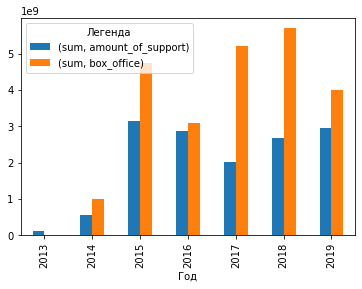

In [139]:
data_sponsored_films.pivot_table(index="year",values=["amount_of_support","box_office"],aggfunc=["sum"]).plot(kind="bar",xlabel="Год");
plt.legend(title="Легенда");


<div class="alert alert-block alert-danger">
 
### Комментарий ревьюера
    
#### Ошибка

Легенда нужна и тут

<div class="alert-info">
<br>Исправил


Каждый год суммарные кассовые сборы фильмов (или конкретных проектов, финансируемых государством) превышали затраты государства на их производство и поддержку.

In [1732]:
data_sponsored_films.query('ratings > -1').pivot_table(index="year",values="ratings",aggfunc="median")

,ratings
year,
2013,6.70
2014,6.35
2015,6.20
2016,6.05
2017,6.20
2018,6.30
2019,6.20


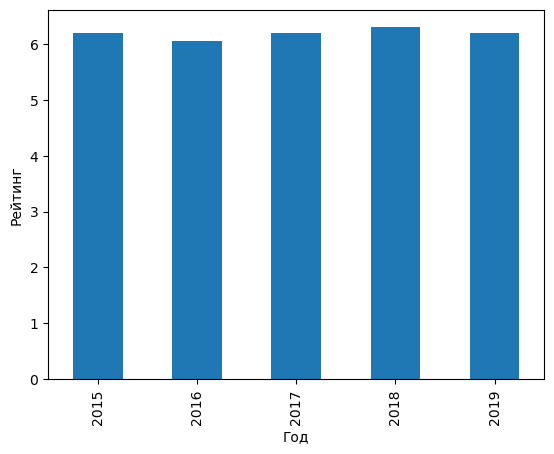

In [1739]:
data_sponsored_films.query('ratings > -1 and year>=2015').pivot_table(index="year",values="ratings",aggfunc="median").plot(kind="bar",legend=False,xlabel="Год",ylabel="Рейтинг");

Из графика видно, что рейтинг с 2015 по 2019 года одинаковый, так что это еще раз доказывает, что рейтинг фильмов не влияет на сумму сборов.

<div class="alert alert-block alert-success">
 
### Комментарий ревьюера
    
#### Успех

Выводы соответствуют графику

In [1746]:
data_sponsored_films.query('financing_source == "Министерство культуры, Фонд кино"').shape[0]

21

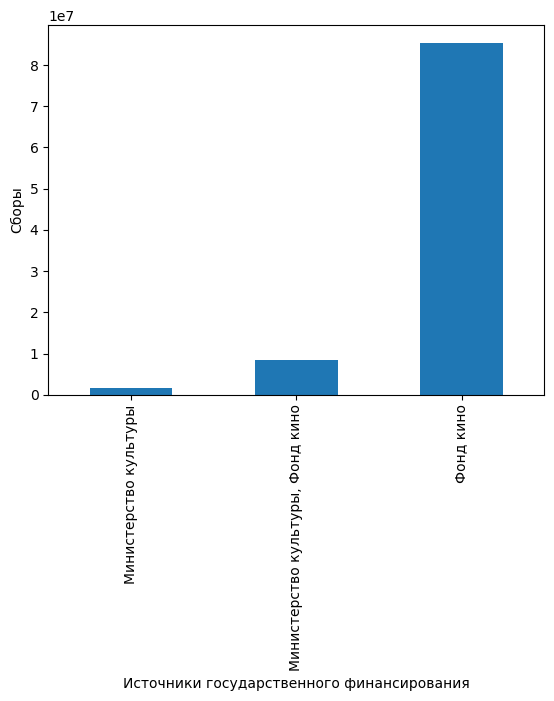

In [1743]:
data_sponsored_films.pivot_table(index="financing_source",values="box_office",aggfunc="median").plot(kind="bar",legend=False,xlabel="Источники государственного финансирования",ylabel="Сборы");

Можно заметить, что фильмы, финансируемые "Фондом кино", демонстрируют наивысшие кассовые сборы.

Вывод:
1) Подготовка данных:

* Заполнили пропущенные значения
* Исправили типы данных в проблемных столбцах
* Удалили неявные дубликаты
* Добавили новые расчетные столбцы для удобства анализа

2) Ключевые выводы исследовательского анализа:

* Наиболее полные данные представлены за 2017 год, наименее полные - за 2010 год
* Максимальная сумма сборов зафиксирована в 2017 году.
* Минимальная сумма сборов наблюдалась в 2010 году.
* Присутствует разница между средней и медианной суммой сборов.
* Наибольшую кассовую эффективность демонстрируют фильмы с рейтингом 6+
  
3) Анализ государственной поддержки:

* Суммарные кассовые сборы фильмов стабильно превышают затраты государства на их производство
* Наибольшие сборы демонстрируют фильмы, получившие поддержку "Фонда кино"

3.1) Корреляционный анализ:

* Не выяслено значимой корреляции между:
  * Рейтингом фильма и долей государственной поддержки
  * Кассовыми сборами и долей государственной поддержки
  * Кассовыми сборами и рейтингом фильма
    
* Источник государственного финансирования не оказывает влияния на рейтинг фильма


<div class="alert alert-block alert-success">
 
### Комментарий ревьюера
    
#### Успех

Итоговый вывод содержит всю самую полезную информацию, которая поможет сформировать представление о рынке кино для Министерства Культуры.

<div class="alert alert-block alert-info">

## Итоговый комментарии от ревьюера:
    
#### Успех

Поздравляю тебя с выполнением твоего первого Сборного проекта. Мне показалось, что работа выполненна прекрасно и ты здорово постарался. Понравилось, что ты хорошо владеешь отличными навыками Предобработки данных. А еще особенно ценно, что ты везде пишешь аргументацию своим действиям. Так, если проект попадет в руки незнакомому человеку, он сможет разобраться. Это тебе очень пригодится в будущем.

В проекте осталось пару замечаний:
    
* Сделать проверку данных по количеству после объединения.
* Добавить промежуточные выводы. 
       
Еще я оставил рекомендации. Очень надеюсь, что ты учтешь их в этом и последующих проектах.
    
    
Жду проект после доработки. Уверен, ты справишься.
</div>